# 06. pytorch transfer learning (전이 학습)

# 전이 학습
: 다른 문제를 해결하면서 모델이 학습한 패턴(= 가중치, weights)을 가져와 우리 문제에 활용하는 방법

- 사용예시
1. 컴퓨터 비전 모델이 ImageNet 같은 데이터셋(수백만 장의 이미지)에서 학습한 패턴을 가져와
우리의 FoodVision Mini 모델에 사용할 수 있음 <br>

2. 대량의 텍스트를 학습한 언어 모델(language model) 의 패턴을 가져와 
다양한 텍스트를 분류하는 모델의 기반으로 사용할 수도 있음 <br>

- 전이 학습을 사용하는 이유

1. 이미 검증된 모델 활용 가능
우리 문제와 유사한 문제에서 잘 작동하는 것으로 입증된 모델(보통 신경망 구조)을 활용할 수 있음 <br>

2. 이미 학습된 패턴 재사용 가능
우리 데이터와 유사한 데이터에서 이미 학습된 패턴을 사용할 수 있음<br>
-> 이로 인해 적은 양의 데이터로도 좋은 성능을 얻을 수 있음<br>


- 연구와 실무 모두에서 효과가 입증된 방법 -> 가능한 경우 전이 학습을 사용하는 것을 권장 <br>
처음부터 모델을 학습하는 것(training from scratch)보다 비용과 시간 측면에서 전이 학습이 훨씬 더 유리하다는 결과 입증됨

*내 문제에 사용할 수 있는 사전 학습 모델이 이미 존재할까-> 란 질문을 하는 것이 딥러닝 문제 시작할 때 좋은 습관

#  진행 단계

0. 환경 설정 (Getting setup) <br>
지금까지 여러 섹션에서 유용한 코드들을 많이 작성했습니다.
👉 이를 다시 다운로드해서 재사용할 수 있도록 준비

1. 데이터 가져오기 (Get data)<br>
지금까지 사용해온
👉 피자, 스테이크, 스시 이미지 분류 데이터셋을 다시 불러와
모델 성능을 개선

2. Dataset과 DataLoader 생성<br>
이전에 작성한 data_setup.py 스크립트를 사용하여
👉 DataLoader를 설정합니다.
(챕터 05. PyTorch Going Modular에서 만든 코드 활용)

3. 사전 학습 모델 가져오기 및 커스터마이징<br>
torchvision.models에서
👉 사전 학습된 모델을 다운로드하고
👉 우리의 문제에 맞게 수정

4. 모델 학습 (Train model)<br>
새로운 사전 학습 모델이
👉 피자, 스테이크, 스시 데이터셋에서 어떻게 작동하는지 확인

이전 챕터에서 만든 학습 함수를 그대로 사용

5. 손실 곡선으로 모델 평가<br>
👉 loss curve를 시각화하여 모델 성능을 분석

과적합(overfitting)인지

과소적합(underfitting)인지 확인

6. 테스트 이미지로 예측하기<br>
평가지표만 보는 것도 중요하지만,

👉 실제 테스트 이미지에 대해
👉 모델이 어떤 예측을 하는지 직접 확인하는 것도 매우 중요

✔️ 핵심: 시각화, 시각화, 시각화!

# 0. 환경 설정 (getting setup)

- 이전 섹션 05. PyTorch Going Modular에서 만든 Python 스크립트들을 재사용할 예정

In [1]:
try:
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular import data_setup, engine

In [3]:
import os
print(os.listdir("going_modular"))

['data_setup.py', 'engine.py', 'model_builder.py', 'train.py', 'utils.py', '__pycache__']


In [4]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
torch.cuda.is_available()

True

# 1. 데이터 가져오기 (Get data)

- 전이 학습이 이전에 직접 만든 모델과 어떻게 다른지 비교하기 위해,
지금까지 FoodVision Mini에서 사용해온 동일한 데이터셋을 다시 다운로드할 것
- 강의 GitHub에 있는 pizza_steak_sushi.zip 데이터셋을 다운로드하고 압축을 해제하기


In [8]:
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

data\pizza_steak_sushi directory exists.


In [9]:
# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

# 2. Dataset과 DataLoader 생성

- 이미 going_modular 디렉토리를 다운로드했기 때문에,
섹션 05 (PyTorch Going Modular)에서 만들었던 data_setup.py 스크립트를 사용해 <br>
DataLoader를 준비하고 설정할 수 있음

- 하지만 이번에는 torchvision.models의 사전 학습 모델을 사용할 것이기 때문에,
이미지를 먼저 처리하기 위한 특정 transform이 필요함

# 2.1 torchvision.models용 transform 만들기 (수동 생성)

*torchvision v0.13+부터는 데이터 transform을 만드는 방식이 업데이트됨 <br>
기존 방식은 "수동 생성(manual creation)" <Br>
새로운 방식은 "자동 생성(auto creation)"

- 사전 학습된 모델을 사용할 때 주의 할 점 <br>
-> 모델에 넣는 데이터는, 모델이 원래 학습할 때 사용했던 데이터와 동일한 방식으로 전처리되어야 함

In [15]:
# transform 파이프라인 만들기 - 사전 학습 모델에 맞는 전처리 목적
manual_transforms = transforms.Compose([    #여러 개의 transform을 순서대로 적용하기 위해 Compose를 사용
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1 , 이미지를 텐서로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)- 평균
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel)- 분산
])

- 05.PyTorch Going Modular Part 2에서 만든 data_setup.py 스크립트의 create_dataloaders 함수를 사용할 수 있음

- batch_size=32로 설정하여 모델이 한 번에 32개의 샘플씩 미니배치로 학습하도록 함

- 또한, 위에서 만든 transform 파이프라인을 적용하기 위해 transform=manual_transforms로 설정

In [20]:
# Create training and testing DataLoaders as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,   # 
                                                                               transform=manual_transforms, # resize, convert images to between 0 & 1 and normalize them
                                                                               batch_size=32) # set mini-batch size to 


train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x20dcc73b100>,
 ['pizza', 'steak', 'sushi'])

In [ ]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

- EfficientNet_B0_Weights → 우리가 사용할 모델 아키텍처의 가중치 종류 <br>
(torchvision에는 다양한 모델 구조가 존재함)<br>
- DEFAULT → 해당 모델에서 가장 성능이 좋은 가중치<br>
(ImageNet 기준 최고 성능)

In [21]:
# 사전 학습된 가중치를 만들 때 사용된 transform 가져오기
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

- auto_transforms → 선택한 모델 아키텍처에 맞게 자동으로 생성됨 <br>
- weights.transforms()를 사용하면<br>
장점 :  사전 학습 모델이 학습될 때 사용했던 것과 완전히 동일한 전처리를 적용할 수 있음<br>
단점 : 커스터마이징이 제한됨 - 자동 방식은 정해진 transform을 사용해야 함


In [22]:
# # 학습/테스트 DataLoader 생성 + 클래스 이름 가져오기
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transforms, # perform same data transforms on our own data as the pretrained model
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x20dd3f9fe50>,
 ['pizza', 'steak', 'sushi'])

# 3. 사전 학습 모델 가져오기 (Getting a pretrained model)

전이 학습의 핵심 아이디어 -> 내 문제와 비슷한 문제에서 이미 잘 작동하는 모델을 가져와서,
내 상황에 맞게 커스터마이징하는 것

- torchvision.models에서
사전 학습된 이미지 분류 모델들을 사용할 수 있음


# 3.1 어떤 사전 학습 모델을 사용해야 할까?
-> 문제의 특성과 사용하는 디바이스에 따라 달라짐

- 일반적으로 모델 이름에 있는 숫자가 클수록 성능은 좋아지지만, 모델 크기도 커짐

- 성능이 좋은 모델일수록 너무 커서 일부 디바이스에서는 사용하기 어려울 수 있음

- 성능 vs 속도 vs 모델 크기 사이의 균형을 맞춰야 함

# 3.2 사전 학습 모델 설정하기

- 우리가 사용할 모델 : torchvision.models.efficientnet_b0()<br>
- 우리가 만들 모델 <br>
torchvision.models의 사전 학습된 EfficientNet_B0 모델을 가져와서, 출력층을 피자, 스테이크, 스시 이미지 분류 문제에 맞게 수정한 형태

- EfficientNet_B0의 ImageNet 사전 학습 가중치는 앞서 transform을 만들 때 사용했던 것과 동일한 코드로 설정할 수 있음

In [24]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT  # ImageNet 기준 가장 성능 좋은 가중치

--> 해당 모델이 이미 수백만 장의 이미지로 학습되어 <br>
이미지 데이터에 대한 좋은 기본 표현(기초적인 특징 이해 능력)을 가지고 있다는 뜻

In [26]:
# 사전 학습된 EfficientNet_B0 모델을 불러오고, 디바이스(GPU/CPU)에 올리기

# 사용할 사전 학습 가중치 선택
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT = best available weights 
model = torchvision.models.efficientnet_b0(weights=weights).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\yoonseo/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 104MB/s]


- efficientnet_b0 모델은 크게 세 가지 부분으로 구성됨

1. features <br>

: 합성곱층(convolutional layers)과 다양한 활성화층으로 이루어짐

이미지 데이터의 기본적인 특징 표현을 학습함

이 부분은 보통 feature extractor(특징 추출기) 라고도 부른다
→ “모델의 기본 레이어들이 이미지의 다양한 특징을 학습한다”

2. avgpool<br>

features 층의 출력을 평균내어

하나의 feature vector(특징 벡터) 로 변환함

3. classifier<br>

feature vector를 받아서

출력 클래스 수에 맞는 벡터로 변환

-> efficientnet_b0는 ImageNet으로 학습되었기 때문에

기본적으로 출력 클래스 수 = 1000개 (out_features=1000)

# 3.3 torchinfo.summary()로 모델 요약

- model : 요약 정보를 확인하고 싶은 모델

- input_size : 모델에 입력할 데이터 형태(shape)
efficientnet_b0의 경우: (batch_size, 3, 224, 224)

- col_names
→ 모델 요약에서 보고 싶은 정보 컬럼들

- col_width
→ 각 컬럼의 너비 설정

- row_settings
→ 각 행(row)에 어떤 정보를 표시할지 설정

In [27]:
# torchinfo.summary()를 사용해서 -> 모델 구조를 표 형태로 출력
summary(model=model, 
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # 주석 풀면 출력을 더 간단하게 줄일 수 있음
        col_names=["input_size", "output_size", "num_params", "trainable"],     # 출력할 정보
        col_width=20,
        row_settings=["var_names"]  # 각 행의 레이어 이름
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

- 이미지 데이터가 모델을 통과하면서 -> 입력과 출력의 크기가 어떻게 변하는지 모두 확인할 수 있음 <br>
- 또한 데이터의 다양한 패턴을 인식하기 위해 -> 훨씬 더 많은 파라미터(사전 학습된 가중치)가 사용된다는 것도 알 수 있음 <br>

--> 비교를 위해 보면:

이전에 사용했던 TinyVGG 모델은
→ 8,083개의 파라미터

반면 efficientnet_b0는
→ 5,288,548개의 파라미터

 약 654배 증가한 것

# 3.4 ) 기본 모델을 고정하고 출력층을 우리 문제에 맞게 변경하기

- 사전 학습된 모델의 일부 기본 레이어(보통 features 부분)를 동결(freeze)하고, 출력 레이어(또는 head / classifier 레이어)를 우리 문제에 맞게 수정하는 것<br>

- 사전 학습된 모델의 출력은 ->  출력 레이어를 변경하여 우리의 문제에 맞게 커스터마이징할 수 있음<br>

- 기존의 torchvision.models.efficientnet_b0() <br>
-ImageNet 데이터셋(1000개 클래스)으로 학습되었기 때문 -> out_features=1000으로 설정되어 있음

- 피자, 스테이크, 스시 3개 클래스만 분류하면 되므로  out_features=3으로 바꿔야 함 <br>

- efficientnet_b0 모델의 features 부분의 모든 레이어/파라미터를 동결(freeze)해보기 <br>
-레이어를 동결 : 학습 과정에서 해당 레이어를 변경하지 않고 그대로 유지하는 것<br>
-requires_grad=False로 설정해 동결하기<br>
-requires_grad=False인 파라미터는 PyTorch가 gradient(기울기)를 계산하지 않음 -> 업데이트하지 않음<br>

In [28]:
# 모델의 "features" 부분(특징 추출기)에 있는 모든 기본 레이어를 requires_grad=False로 설정하여 동결(freeze)
for param in model.features.parameters() :
    param.requires_grad = False

-> 특징 추출기(feature extractor) 레이어들이 동결됨

- 사전 학습된 모델의 출력층(또는 classifier 부분)을 우리 문제에 맞게 조정해보기
-현재 사전 학습된 모델은 out_features=1000으로 설정되어 있음 (ImageNet의 1000개 클래스를 기준으로 학습되었기 때문)
-하지만 우리는 피자, 스테이크, 스시 3개 클래스만 필요
-모델의 classifier 부분을 새로운 레이어들로 구성하여 변경할 수 있음

- 현재 classifier의 구조
(classifier): Sequential(
    (0): Dropout(p=0.2, inplace=True)
    (1): Linear(in_features=1280, out_features=1000, bias=True)

1. Dropout레이어는 torch.nn.Dropout(p=0.2, inplace=True) 그대로 유지할 것임<br>
*Dropout이란?<br>
: Dropout 레이어는 두 신경망 레이어 사이의 연결을 확률 p로 무작위 제거함<br>
-이 방법은 모델이 과적합(overfitting)되는 것을 방지하기 위한 것으로, <br>
남아있는 연결들이 제거된 부분을 보완하도록 학습하게 만듬(즉, 더 일반화된 특징을 학습하도록 유도)


2. Linear 출력 레이어에서 in_features=1280은 그대로 유지하고
out_features는 클래스 개수 len(['pizza', 'steak', 'sushi']) = 3로 변경할 거임

3. 새로 만든 classifier 레이어는 모델과 동일한 디바이스(device)에 있어야 함

In [30]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# 3번 진행
output_shape = len(class_names)

# classifier를 새로 만들고 device(GPU/CPU)에 올림
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True), # dropout 레이어 
    torch.nn.Linear(in_features=1280, 
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

In [31]:
# # Do a summary *after* freezing the features and changing the output classifier layer (uncomment for actual output)
summary(model,      # 요약할 모델 (수정된 EfficientNet)
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,  # 출력 자세히 보기 설정- 0은 간단하게 출력이라는 뜻
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]      # 각 행에 레이어 이름 표시
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

1. Trainable 열<br>
-features 부분에 있는 많은 기본 레이어들의 Trainable 값이 False로 되어 있는 것을 볼 수 있음<br>
-우리가 해당 레이어들의 requires_grad=False로 설정했기 때문<br>
-이 값을 다시 바꾸지 않는 한, 이 레이어들은 이후 학습 과정에서 업데이트되지 않음<br>

2.  classifier의 출력 형태<br>
-모델의 classifier 부분은 이제 출력 형태가 [32, 1000]이 아니라 [32, 3]이 됨 + 또한 Trainable 값이 True  <br>
--> 이는 classifier의 파라미터가 학습 중에 업데이트된다는 의미<br>
--> 즉, features 부분 → 이미지의 기본 특징을 추출<br>
classifier 부분 → 그 특징을 바탕으로 우리 문제(피자, 스테이크, 스시)에 맞게 학습

3. 학습 가능한 파라미터 감소<br>
이전에는 5,288,548개의 trainable 파라미터가 있었지만,
features 레이어를 동결하고 classifier만 학습하도록 바꾼 결과 <br>
--> 이제 3,843개만 학습 가능(trainable)<br>

-하지만4,007,548개의 non-trainable 파라미터는 여전히 존재하며
이들은 입력 이미지의 기본 특징을 추출하는 데 사용함

# 4. 모델 학습 (Train Model)

- 이제 부분적으로 동결된 사전 학습 모델과 커스터마이징된 classifier를 준비했으니, <br>
전이 학습이 실제로 어떻게 동작하는지 확인해보기

- 학습을 시작하기 위해 손실 함수(loss function)와 옵티마이저(optimizer)를 설정하기 <br>
-다중 클래스 분류 문제를 다루고 있으므로  손실 함수로 nn.CrossEntropyLoss()를 사용<br>
-옵티마이저는 torch.optim.Adam()을 사용하고 학습률은 lr=0.001로 설정 <br>

In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

- 05. PyTorch Going Modular 섹션 04에서 정의한 train() 함수를 사용 <br>
-이 train() 함수는 going_modular 디렉토리 안의 engine.py 스크립트에 있음

- 모델이 5 epoch동안 학습하는데 걸리는 시간 확인하기
(현재는 모델의 대부분 파라미터를 동결했기 때문에 classifier의 파라미터만 학습하게 됨)

In [33]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Setup training and save the results
results = engine.train(model=model,         # engine.py 안에 train함수 사용
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] 총 학습시간: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0924 | train_acc: 0.3984 | test_loss: 0.9131 | test_acc: 0.5398
Epoch: 2 | train_loss: 0.8717 | train_acc: 0.7773 | test_loss: 0.7911 | test_acc: 0.8153
Epoch: 3 | train_loss: 0.7648 | train_acc: 0.7930 | test_loss: 0.7462 | test_acc: 0.8561
Epoch: 4 | train_loss: 0.7109 | train_acc: 0.7539 | test_loss: 0.6372 | test_acc: 0.8655
Epoch: 5 | train_loss: 0.6255 | train_acc: 0.7852 | test_loss: 0.6260 | test_acc: 0.8561
[INFO] 총 학습시간: 112.205 seconds


-> 이전에 만들었던 모델보다 더 좋은 성능을 냄

- EfficientNet_B0를 backbone으로 사용한 결과, 테스트 데이터셋에서 약 85% 이상의 정확도를 달성함 <br>
-TinyVGG로 얻었던 성능의 거의 두 배 수준임 <br>
-EfficientNet_B0를 backbone으로 사용 : EfficientNet_B0의 feature 추출 부분을 가져와 우리 문제에 사용

# 5. 손실 곡선으로 모델 평가

- loss curve 시각화하기
-loss curve는 04. PyTorch Custom Datasets 섹션 7.8에서 만든
plot_loss_curves() 함수를 사용해 그릴 수 있음

- 이 함수는 helper_functions.py 파일에 저장되어 있으므로, <br>
 먼저 import를 시도하고, 없다면 파일을 다운로드하기

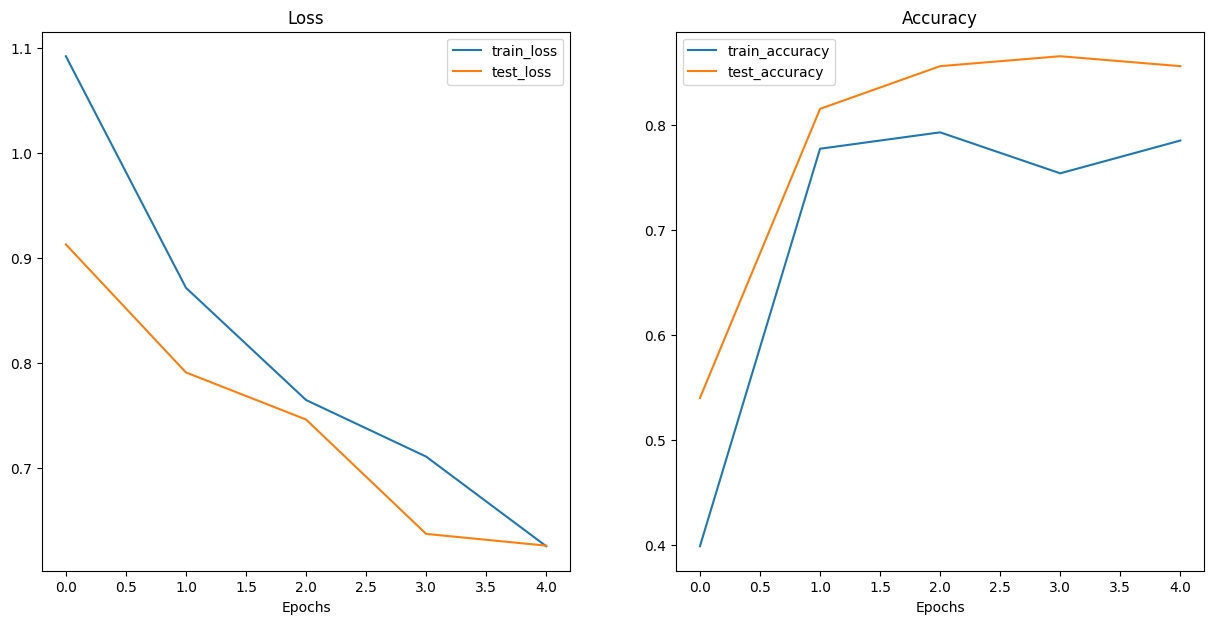

In [34]:
# Get the plot_loss_curves() function from helper_functions.py, download the file if we don't have it
try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves

# Plot the loss curves of our model
plot_loss_curves(results)

-> train과 test 데이터 모두에서 loss가 올바른 방향으로 감소  & accuracy도 점점 증가하는 추세를 보임 <br>
-->  매우 훌륭함


# 6. 테스트 이미지로 예측하기

- 실제 예측 결과를 확인하기 위해 테스트 데이터셋(학습에 사용되지 않은 이미지)에 대해 모델의 예측을 수행하고 시각화 하기

- 모델이 이미지를 예측하기 위해선 입력 데이터가 학습 때와 동일한 형식이어야 함. 다음 조건을 만족해야 함
1. 동일한 형태(shape): 다르면 shape error 발생
2. 동일한 데이터 타입(dtype): 예를 들어 torch.int8과 torch.float32가 다르면 오류 발생
3. 동일한 디바이스(device): 모델과 다른 디바이스에 있으면 오류 발생
4. 동일한 전처리(transform): 학습 때와 다른 방식이면 예측이 부정확해질 수 있음

- 이 과저을 위해 pred_and_plot_image() 함수 만들어야 함. 이 함수는 다음을 수행.
학습된 모델, 클래스 이름 리스트, 이미지 경로, 이미지 크기, transform, 디바이스를 입력으로 받는다 <br>
PIL.Image.open()으로 이미지 불러오기<br>
이미지에 적용할 transform 생성 (manual_transforms 또는 weights 기반 transform 사용 가능)<br>
모델을 target device로 이동<br>
model.eval()과 inference mode 활성화 (Dropout 등 비활성화)<br>
이미지에 transform 적용 후 torch.unsqueeze(dim=0)으로 batch 차원 추가 → [batch_size, channels, height, width] 형태로 변환<br>
모델에 입력하여 예측 수행<br>
torch.softmax()로 확률 계산<br>
torch.argmax()로 최종 클래스 선택<br>
matplotlib으로 이미지 출력 후 예측 클래스와 확률을 제목으로 표시<br>


In [36]:
from typing import List, Tuple

from PIL import Image

# 1. Take in a trained model, class names, image path, image size, a transform and target device
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str, 
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    
    
    # 2. Open image
    img = Image.open(image_path)

    # 3. transform이 있으면 그걸 쓰고, 없으면 새로 만듦
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([      # transform 없으면 기본 전처리
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    ### Predict on image ### 

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
      # 6. 이미지 변환 + 배치 차원 추가 (model requires samples in [batch_size, color_channels, height, width])
      ## 이미지 1장일 경우 batch 형태를 입력 형태에 맞게 맞춰줘야하기 때문
      transformed_image = image_transform(img).unsqueeze(dim=0)

      # 7. 모델에 넣어서 예측값 (logits) 얻기
      target_image_pred = model(transformed_image.to(device))

    # 8. logits → 확률로 변환 (using torch.softmax() for 다중 클래스 분류)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 9. Convert prediction probabilities -> prediction labels - 가장 높은 확률의 클래스 선택
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 10. Plot image with predicted label and probability - 이미지 출력
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);

1.  list(Path(test_dir).glob("*/*.jpg"))를 사용하면 테스트 이미지 경로들의 리스트를 얻을 수 있음 <br>
glob() 메서드의 *: “이 패턴에 맞는 모든 파일”을 의미. .jpg로 끝나는 모든 파일(우리 이미지 전체)을 뜻 함<br>

2. Python의 random.sample(population, k)을 사용해서 이 중 일부를 무작위로 선택<br>
여기서 population은 샘플링할 대상(시퀀스)이고, k는 뽑을 샘플의 개수

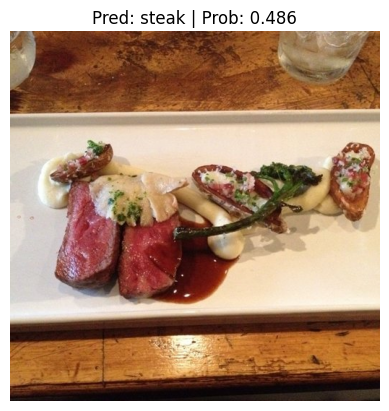

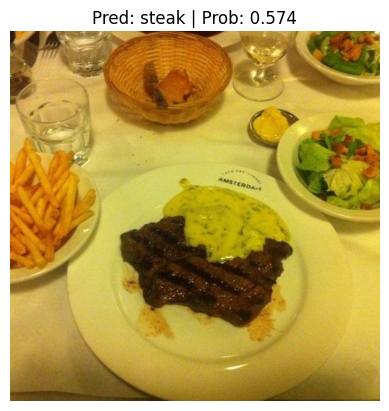

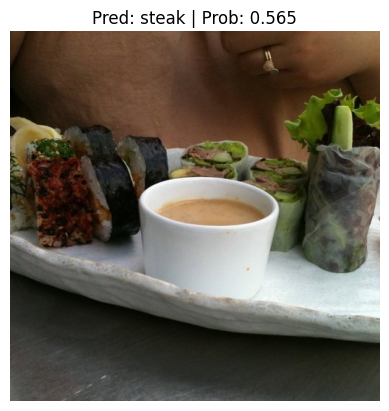

In [37]:
# Get a random list of image paths from test set
import random
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # 테스트 이미지 경로들의 리스트 가져오기
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot_image(model=model, 
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224, 224))

# 6.1 커스텀 이미지로 예측하기

- 훈련 데이터나 테스트 데이터가 아닌, 자신만의 데이터로 예측해보기
1. pizza-dad.jpeg 이미지(아버지가 피자를 먹고 있는 사진)를 불러오기
2. 위에서 만든 pred_and_plot_image() 함수에 이 이미지를 넣어서 어떤 결과가 나오는지 확인

data\04-pizza-dad.jpeg already exists, skipping download.


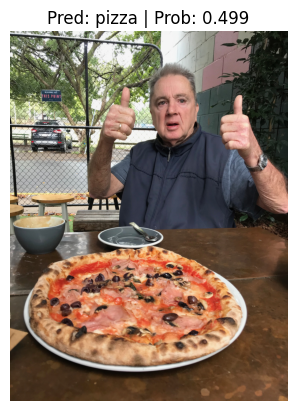

In [38]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# 없으면 다운로드
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

# 핵심 요약

1. 전이 학습(Transfer Learning)을 사용하면 비교적 적은 양의 커스텀 데이터로도 좋은 결과를 얻을 수 있음
2. 전이 학습의 강점을 알았다면, 문제를 시작할 때 항상 “이 문제에 이미 잘 작동하는 모델이 존재할까?” 를 먼저 생각해보는 것이 좋음
3. 사전 학습된 모델을 사용할 때는, 내 데이터가 원래 모델이 학습된 방식과 동일하게 전처리/포맷되어야 함. 그렇지 않으면 성능이 떨어질 수 있음
4. 커스텀 데이터로 예측할 때도 마찬가지로, 모델이 학습했던 데이터와 동일한 형식으로 맞춰줘야 함
5. 사전 학습 모델은 PyTorch 도메인 라이브러리, HuggingFace Hub, 그리고 timm(PyTorch Image Models) 같은 다양한 곳에서 찾을 수 있음